In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Cohort Analysis
### Do customers come back after their first purchase?

In [2]:
conn=sqlite3.connect('ecommerce.db')

In [3]:
events=pd.read_sql('''select * from events''',conn )

In [4]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [5]:
#Purchase Data
transactions = pd.read_sql("""SELECT visitorid, itemid, timestamp
FROM events
WHERE event='transaction'
ORDER BY visitorid,timestamp
""",conn)

transactions.head()

,visitorid,itemid,timestamp
0,172,465522,1439602141230
1,172,10034,1439602141686
2,186,49029,1439397297040
3,264,459835,1441647285614
4,264,161949,1441647285708


In [6]:
# convert timestamp
transactions["Purchase_Date"] = pd.to_datetime(transactions["timestamp"],unit="ms")

transactions.head()

,visitorid,itemid,timestamp,Purchase_Date
0,172,465522,1439602141230,2015-08-15 01:29:01.230
1,172,10034,1439602141686,2015-08-15 01:29:01.686
2,186,49029,1439397297040,2015-08-12 16:34:57.040
3,264,459835,1441647285614,2015-09-07 17:34:45.614
4,264,161949,1441647285708,2015-09-07 17:34:45.708


In [7]:
# purchase month
transactions["Purchase_Month"] = transactions["Purchase_Date"].dt.to_period("M").astype(str)

transactions.head()

,visitorid,itemid,timestamp,Purchase_Date,Purchase_Month
0,172,465522,1439602141230,2015-08-15 01:29:01.230,2015-08
1,172,10034,1439602141686,2015-08-15 01:29:01.686,2015-08
2,186,49029,1439397297040,2015-08-12 16:34:57.040,2015-08
3,264,459835,1441647285614,2015-09-07 17:34:45.614,2015-09
4,264,161949,1441647285708,2015-09-07 17:34:45.708,2015-09


In [8]:
# first purchase
first_purchase = pd.read_sql("""
WITH purchases AS (SELECT visitorid,
date(timestamp/1000,'unixepoch') AS purchase_date

FROM events

WHERE event='transaction')

SELECT

    visitorid,

    MIN(purchase_date) AS first_purchase,
    strftime('%Y-%m',MIN(purchase_date)) AS cohort_month

FROM purchases

GROUP BY visitorid

""",conn)

first_purchase.head()

,visitorid,first_purchase,cohort_month
0,172,2015-08-15,2015-08
1,186,2015-08-12,2015-08
2,264,2015-09-07,2015-09
3,419,2015-07-29,2015-07
4,539,2015-06-16,2015-06


In [9]:
#unixepoch-Treat this number as the number of seconds since 1 January 1970

In [10]:
first_purchase["cohort_month"].value_counts().sort_index()

cohort_month
2015-05    2546
2015-06    2652
2015-07    2880
2015-08    2422
2015-09    1219
Name: count, dtype: int64

## Customer Cohort Distribution

Customers were assigned to cohorts based on the **month of their first purchase**.

### Key Findings

- The dataset contains **5 monthly customer cohorts**, spanning from **May 2015 to September 2015**.
- **July 2015** acquired the largest number of new customers (**2,880**), representing the strongest acquisition month in the dataset.
- **September 2015** has the smallest cohort (**1,219 customers**), which is expected because it represents only a partial month at the end of the observation period.
- Customer acquisition remained relatively stable between **May and August**, with each cohort contributing approximately **2,400–2,900 new customers**.

### Business Insights

- The business consistently acquired new customers throughout the observation period, indicating steady acquisition performance.
- The noticeably smaller September cohort should not be interpreted as declining acquisition because the dataset ends during September, making it an incomplete observation period.
- The next step is to evaluate **customer retention** within each cohort to determine whether larger acquisition cohorts also generated stronger long-term customer engagement.

In [11]:
# cohort index-How many months after their first purchase did a customer purchase again?

In [12]:
cohort_data = pd.read_sql("""
WITH purchases AS (SELECT visitorid, date(timestamp/1000,'unixepoch') AS purchase_date
FROM events
WHERE event='transaction'),

first_purchase AS (

SELECT visitorid, MIN(purchase_date) AS first_purchase_date, strftime('%Y-%m',MIN(purchase_date)) AS cohort_month
FROM purchases
GROUP BY visitorid)

SELECT p.visitorid, fp.cohort_month,strftime('%Y-%m',p.purchase_date) AS purchase_month,
 ( ( CAST(strftime('%Y',p.purchase_date) AS INTEGER) - CAST(strftime('%Y',fp.first_purchase_date) AS INTEGER)) * 12 +
 ( CAST(strftime('%m',p.purchase_date) AS INTEGER) - CAST(strftime('%m',fp.first_purchase_date) AS INTEGER) )) AS cohort_index

FROM purchases p

JOIN first_purchase fp

ON p.visitorid = fp.visitorid

ORDER BY p.visitorid, p.purchase_date

""",conn)

cohort_data.head()

,visitorid,cohort_month,purchase_month,cohort_index
0,172,2015-08,2015-08,0
1,172,2015-08,2015-08,0
2,186,2015-08,2015-08,0
3,264,2015-09,2015-09,0
4,264,2015-09,2015-09,0


In [13]:
#Retention Table-
retention = pd.read_sql("""
WITH purchases AS (SELECT visitorid, date(timestamp/1000,'unixepoch') AS purchase_date
FROM events
WHERE event='transaction'),

first_purchase AS (
SELECT visitorid, MIN(purchase_date) AS first_purchase_date, strftime('%Y-%m',MIN(purchase_date)) AS cohort_month
FROM purchases
GROUP BY visitorid),

cohort_data AS (
SELECT DISTINCT p.visitorid, fp.cohort_month, strftime('%Y-%m',p.purchase_date) AS purchase_month,

( ( CAST(strftime('%Y',p.purchase_date) AS INTEGER)  - CAST(strftime('%Y',fp.first_purchase_date) AS INTEGER)) * 12

 +

( CAST(strftime('%m',p.purchase_date) AS INTEGER) - CAST(strftime('%m',fp.first_purchase_date) AS INTEGER) ) ) AS cohort_index

FROM purchases p

JOIN first_purchase fp

ON p.visitorid=fp.visitorid

)

SELECT

    cohort_month,

    cohort_index,

    COUNT(DISTINCT visitorid) AS customers

FROM cohort_data

GROUP BY

    cohort_month,

    cohort_index

ORDER BY

    cohort_month,

    cohort_index

""",conn)

retention

,cohort_month,cohort_index,customers
0,2015-05,0,2546
1,2015-05,1,76
2,2015-05,2,46
3,2015-05,3,25
4,2015-05,4,14
5,2015-06,0,2652
6,2015-06,1,45
7,2015-06,2,19
8,2015-06,3,11
9,2015-07,0,2880


In [14]:
# converting to retention matrix
retention_matrix = retention.pivot(index="cohort_month",columns="cohort_index",values="customers")

retention_matrix

cohort_index,0,1,2,3,4
cohort_month,,,,,
2015-05,2546.0,76.0,46.0,25.0,14.0
2015-06,2652.0,45.0,19.0,11.0,NaN
2015-07,2880.0,32.0,10.0,NaN,NaN
2015-08,2422.0,36.0,NaN,NaN,NaN
2015-09,1219.0,NaN,NaN,NaN,NaN


In [15]:
# convert to %
retention_pct = round(retention_matrix.div(retention_matrix[0], axis=0) * 100,2)

retention_pct

cohort_index,0,1,2,3,4
cohort_month,,,,,
2015-05,100.0,2.99,1.81,0.98,0.55
2015-06,100.0,1.70,0.72,0.41,NaN
2015-07,100.0,1.11,0.35,NaN,NaN
2015-08,100.0,1.49,NaN,NaN,NaN
2015-09,100.0,NaN,NaN,NaN,NaN


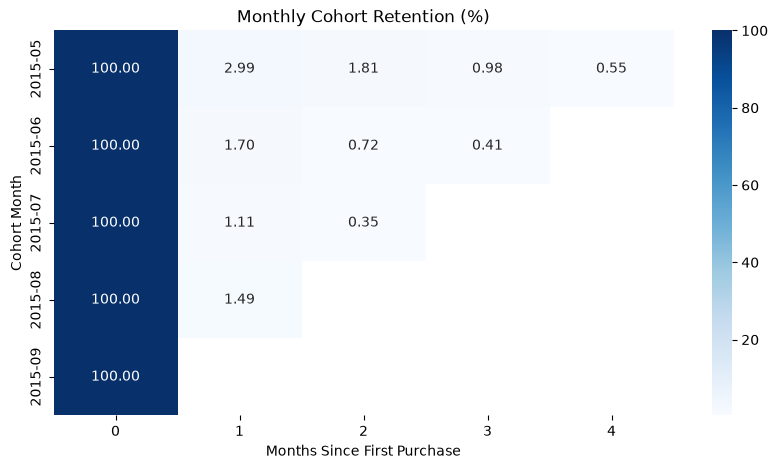

In [16]:
#Heatmap
plt.figure(figsize=(10,5))

sns.heatmap(retention_pct,annot=True,fmt=".2f",cmap="Blues")

plt.title("Monthly Cohort Retention (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.savefig('Monthly Cohort Retention (%).png',dpi=400)
plt.show()

# Cohort Retention Analysis

Customer retention was analyzed by grouping customers into **monthly cohorts** based on their first purchase and tracking the percentage that returned in subsequent months.

## Key Findings

- Every cohort starts at **100%** in Month 0, representing all customers who made their first purchase during that month.
- **May 2015** achieved the strongest one-month retention, with **2.99%** of customers returning in the following month.
- **June (1.70%)**, **July (1.11%)**, and **August (1.49%)** cohorts showed even lower Month 1 retention.
- Retention declines rapidly after the first month:
  - The May cohort falls from **2.99%** in Month 1 to **1.81%** in Month 2, **0.98%** in Month 3, and only **0.55%** by Month 4.
- The September cohort contains only Month 0 because the dataset ends during September, leaving no future months available to measure retention.

## Business Insights

- Customer acquisition remained consistent across the observation period, but **repeat purchasing behavior is extremely weak**.
- Fewer than **3% of customers return after one month**, indicating that most customers make a single purchase and do not return.
- The rapid decline in retention suggests the business relies heavily on **continuous customer acquisition** rather than customer loyalty.
- These findings strongly support the earlier **RFM Analysis**, where:
  - Most buyers were **one-time purchasers**.
  - The **At Risk** segment was the largest customer group.
  - A significant proportion of customers were classified as **Lost Customers**.
- Improving post-purchase engagement, loyalty programs, personalized recommendations, and retention campaigns should be a higher priority than focusing solely on acquiring new customers.

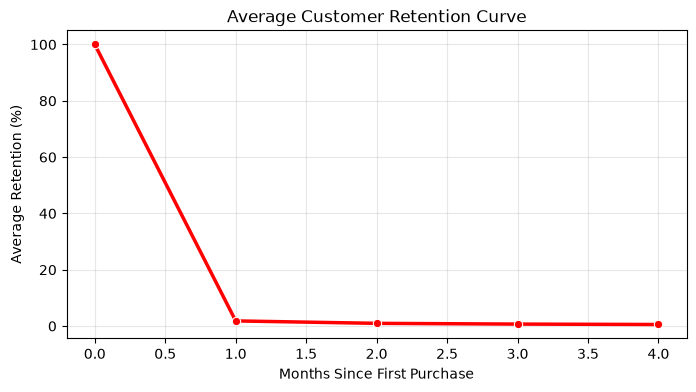

In [17]:
#Retention Curve
avg_retention = retention_pct.mean(axis=0)

plt.figure(figsize=(8,4))

sns.lineplot(x=avg_retention.index,y=avg_retention.values,marker="o",linewidth=2.5, color='red')

plt.title("Average Customer Retention Curve")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Average Retention (%)")
plt.grid(alpha=0.3)
plt.savefig('Average Customer Retention Curve.png',dpi=400)
plt.show()